Step 1: Load Dataset from Google Drive in Colab

**Dataset link: https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset/data**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!


In [13]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [14]:

file_path = '/content/drive/MyDrive/Colab Notebooks/Lab_3_SVM_KKN/breast-cancer.csv'

df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print(f"📐 Shape: {df.shape}")
print("\n🔍 First 5 rows:")
df.head()

✅ Dataset loaded successfully!
📐 Shape: (569, 32)

🔍 First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Data set overview


In [15]:
print("📊 Column Names:")
print(df.columns.tolist())

print("\n📋 Dataset Info:")
print(df.info())

print("\n📈 Basic Statistics:")
print(df.describe())

print("\n🎯 Target Column Value Counts:")
print(df['diagnosis'].value_counts())

📊 Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean          

**Data processing**

Check missing values and Basic cleangin

In [16]:
print("🔍 Missing Values Check:")
print(df.isnull().sum())

print(f"\n✅ Total missing values: {df.isnull().sum().sum()}")

# Drop 'id' column — not useful for prediction
df.drop(columns=['id'], inplace=True)

print("\n✅ 'id' column dropped!")
print(f"📐 New Shape: {df.shape}")

🔍 Missing Values Check:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

✅ Total missing values: 0

✅ 'id' 

Encode Target

In [17]:
# M (Malignant) = 1, B (Benign) = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("✅ Target column encoded!")
print("\n🎯 Target value counts:")
print(df['diagnosis'].value_counts())
print("\nM (Malignant/Cancer) = 1")
print("B (Benign/No Cancer) = 0")

✅ Target column encoded!

🎯 Target value counts:
diagnosis
0    357
1    212
Name: count, dtype: int64

M (Malignant/Cancer) = 1
B (Benign/No Cancer) = 0


Separate Feature and Target

In [18]:
# Features (X) and Target (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"✅ Features shape (X): {X.shape}")
print(f"✅ Target shape  (y): {y.shape}")
print(f"\n📋 Feature columns ({X.shape[1]} total):")
print(X.columns.tolist())

✅ Features shape (X): (569, 30)
✅ Target shape  (y): (569,)

📋 Feature columns (30 total):
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


Train / Valdiation /Test split

In [19]:
from sklearn.model_selection import train_test_split

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("✅ Data split completed!")
print(f"\n📊 Split Summary:")
print(f"   🔵 Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   🟡 Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   🔴 Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

✅ Data split completed!

📊 Split Summary:
   🔵 Training set   : 341 samples (59.9%)
   🟡 Validation set : 114 samples (20.0%)
   🔴 Test set       : 114 samples (20.0%)


NOrmalize /Standard Features

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data — transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("✅ Feature scaling (StandardScaler) applied!")
print("\n📊 Sample mean & std after scaling (Train):")
print(f"   Mean : {X_train_scaled.mean():.6f}  (should be ≈ 0)")
print(f"   Std  : {X_train_scaled.std():.6f}   (should be ≈ 1)")

✅ Feature scaling (StandardScaler) applied!

📊 Sample mean & std after scaling (Train):
   Mean : 0.000000  (should be ≈ 0)
   Std  : 1.000000   (should be ≈ 1)


visualize Class

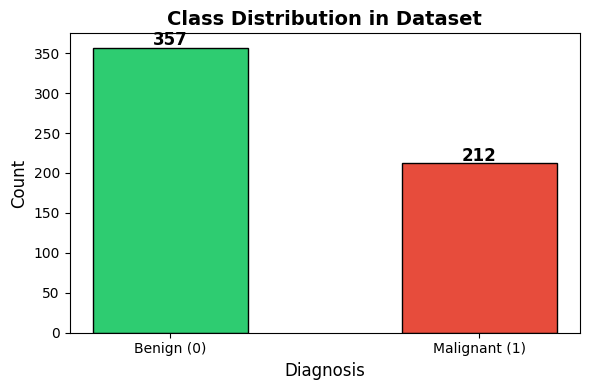

✅ Class distribution plot saved!


In [21]:
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
labels = ['Benign (0)', 'Malignant (1)']
counts = df['diagnosis'].value_counts()

plt.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Count', fontsize=12)

for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("✅ Class distribution plot saved!")

### **STEP 3 : SVM model Training + Hyperemeter Tuning**

Train basic Svm model first

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Basic SVM model with RBF kernel
svm_base = SVC(kernel='rbf', random_state=42, probability=True)
svm_base.fit(X_train_scaled, y_train)

# Check accuracy on validation set
val_pred = svm_base.predict(X_val_scaled)
val_acc = accuracy_score(y_val, val_pred)

print("✅ Basic SVM Model Trained!")
print(f"\n📊 Validation Accuracy (before tuning): {val_acc*100:.2f}%")

✅ Basic SVM Model Trained!

📊 Validation Accuracy (before tuning): 98.25%


Hypermeter tuning with gridSeachcv

In [23]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = [
    {
        'kernel': ['rbf'],
        'C'     : [0.1, 1, 10, 100],
        'gamma' : ['scale', 0.01, 0.1, 1]
    },
    {
        'kernel': ['linear'],
        'C'     : [0.1, 1, 10, 100]
    },
    {
        'kernel': ['poly'],
        'C'     : [0.1, 1, 10],
        'degree': [2, 3, 4],
        'gamma' : ['scale', 0.01]
    }
]

print("🔍 Starting Hyperparameter Tuning...")
print("⏳ This may take 1-2 minutes, please wait...\n")

grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,                    # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,               # use all CPU cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n✅ Hyperparameter Tuning Completed!")
print(f"\n🏆 Best Parameters  : {grid_search.best_params_}")
print(f"🎯 Best CV Accuracy : {grid_search.best_score_*100:.2f}%")

🔍 Starting Hyperparameter Tuning...
⏳ This may take 1-2 minutes, please wait...

Fitting 5 folds for each of 38 candidates, totalling 190 fits

✅ Hyperparameter Tuning Completed!

🏆 Best Parameters  : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
🎯 Best CV Accuracy : 97.36%


Train Final Model with Best Parameters

In [24]:
# Use best model from GridSearch
best_svm = grid_search.best_estimator_

# Evaluate on all sets
train_pred = best_svm.predict(X_train_scaled)
val_pred   = best_svm.predict(X_val_scaled)
test_pred  = best_svm.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
val_acc   = accuracy_score(y_val,   val_pred)
test_acc  = accuracy_score(y_test,  test_pred)

print("✅ Final SVM Model Ready!")
print(f"\n📊 Accuracy Summary:")
print(f"   🔵 Training   Accuracy : {train_acc*100:.2f}%")
print(f"   🟡 Validation Accuracy : {val_acc*100:.2f}%")
print(f"   🔴 Test       Accuracy : {test_acc*100:.2f}%")

print(f"\n⚙️  Best Model Configuration:")
print(f"   Kernel : {grid_search.best_params_.get('kernel')}")
print(f"   C      : {grid_search.best_params_.get('C')}")
print(f"   Gamma  : {grid_search.best_params_.get('gamma', 'N/A')}")
print(f"   Degree : {grid_search.best_params_.get('degree', 'N/A')}")

✅ Final SVM Model Ready!

📊 Accuracy Summary:
   🔵 Training   Accuracy : 98.24%
   🟡 Validation Accuracy : 98.25%
   🔴 Test       Accuracy : 97.37%

⚙️  Best Model Configuration:
   Kernel : rbf
   C      : 1
   Gamma  : scale
   Degree : N/A


RBF karnel - C vs Gamma

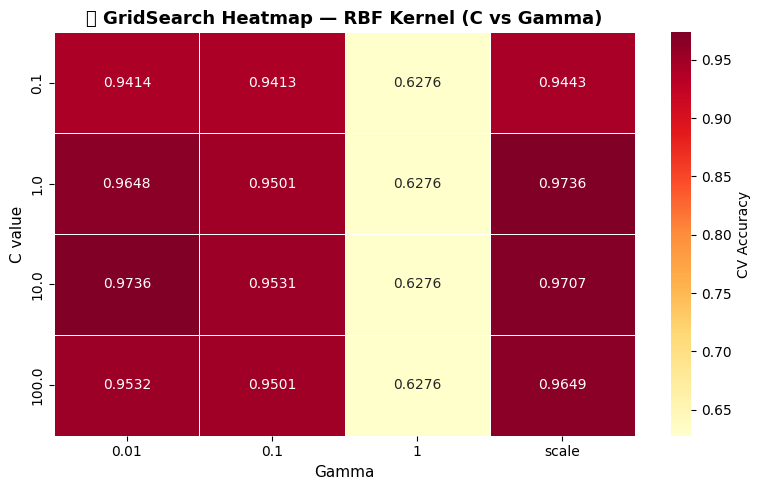

✅ GridSearch Heatmap saved!


In [25]:
import pandas as pd

# Extract RBF results only
cv_results = pd.DataFrame(grid_search.cv_results_)
rbf_results = cv_results[cv_results['param_kernel'] == 'rbf'].copy()

rbf_results['param_C']     = rbf_results['param_C'].astype(float)
rbf_results['param_gamma'] = rbf_results['param_gamma'].astype(str)

# Pivot for heatmap
pivot = rbf_results.pivot_table(
    index='param_C',
    columns='param_gamma',
    values='mean_test_score'
)

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'CV Accuracy'}
)
plt.title('🔥 GridSearch Heatmap — RBF Kernel (C vs Gamma)', fontsize=13, fontweight='bold')
plt.xlabel('Gamma', fontsize=11)
plt.ylabel('C value', fontsize=11)
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150)
plt.show()
print("✅ GridSearch Heatmap saved!")

# **Step 4: Evaluation & All Required Plots**

All Evaluation Metrics

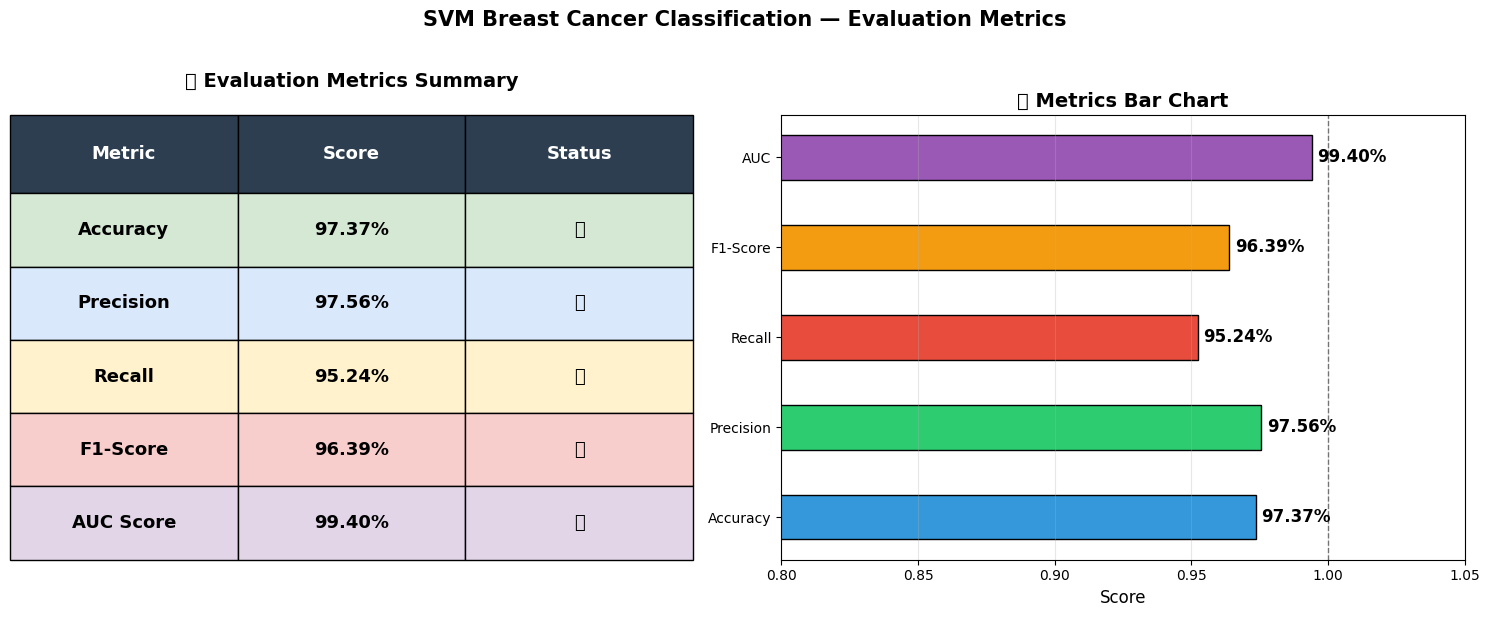

✅ Evaluation Metrics Plot saved!


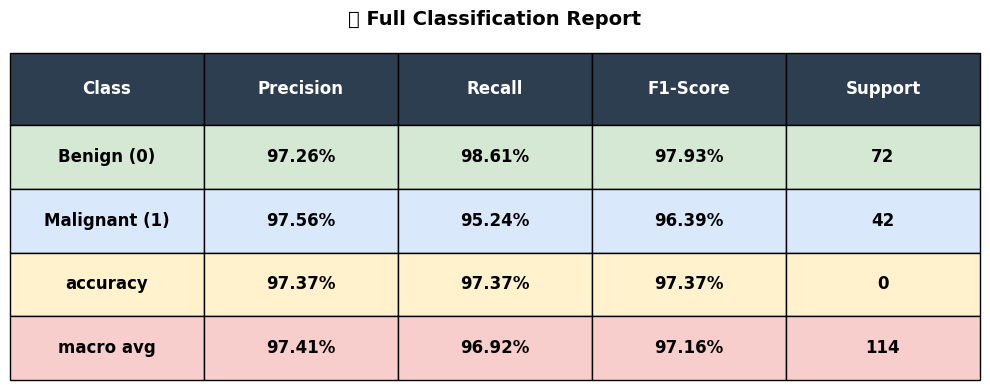

✅ Classification Report Table saved!


In [34]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)

# Get predictions & probabilities
test_pred = best_svm.predict(X_test_scaled)
test_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

# Calculate all metrics
accuracy  = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall    = recall_score(y_test, test_pred)
f1        = f1_score(y_test, test_pred)
auc       = roc_auc_score(y_test, test_prob)

# ============================================
# PLOT 1 — Metrics Summary Visual Table
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Metrics Table as Image ---
metrics_data = [
    ['Accuracy',  f'{accuracy*100:.2f}%',  '✅'],
    ['Precision', f'{precision*100:.2f}%', '✅'],
    ['Recall',    f'{recall*100:.2f}%',    '✅'],
    ['F1-Score',  f'{f1*100:.2f}%',        '✅'],
    ['AUC Score', f'{auc*100:.2f}%',       '✅'],
]

axes[0].axis('off')
table = axes[0].table(
    cellText=metrics_data,
    colLabels=['Metric', 'Score', 'Status'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(13)

# Header style
for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white',
                                fontweight='bold',
                                fontsize=13)
    table[0, j].set_height(0.15)

# Row colors
row_colors = ['#d5e8d4', '#dae8fc', '#fff2cc', '#f8cecc', '#e1d5e7']
for i in range(1, 6):
    for j in range(3):
        table[i, j].set_facecolor(row_colors[i-1])
        table[i, j].set_text_props(fontsize=13, fontweight='bold')
        table[i, j].set_height(0.14)

axes[0].set_title('📊 Evaluation Metrics Summary',
                  fontsize=14, fontweight='bold', pad=20)

# --- Right: Metrics Bar Chart ---
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
metrics_values = [accuracy, precision, recall, f1, auc]
bar_colors     = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = axes[1].barh(metrics_names,
                    metrics_values,
                    color=bar_colors,
                    edgecolor='black',
                    height=0.5)

axes[1].set_xlim([0.8, 1.05])
axes[1].set_title('📊 Metrics Bar Chart',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].axvline(x=1.0,
                color='black',
                linestyle='--',
                linewidth=1,
                alpha=0.5)
axes[1].grid(alpha=0.3, axis='x')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    axes[1].text(bar.get_width() + 0.002,
                 bar.get_y() + bar.get_height()/2,
                 f'{val*100:.2f}%',
                 va='center',
                 fontsize=12,
                 fontweight='bold')

plt.suptitle('SVM Breast Cancer Classification — Evaluation Metrics',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation Metrics Plot saved!")

# ============================================
# PLOT 2 — Full Classification Report Table
# ============================================
report = classification_report(y_test, test_pred,
         target_names=['Benign (0)', 'Malignant (1)'],
         output_dict=True)

report_df = pd.DataFrame(report).transpose().round(4)
report_df = report_df.iloc[:-1]  # Remove last row

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

report_data = []
headers = ['Class', 'Precision', 'Recall', 'F1-Score', 'Support']

for idx, row in report_df.iterrows():
    report_data.append([
        idx,
        f"{row['precision']*100:.2f}%",
        f"{row['recall']*100:.2f}%",
        f"{row['f1-score']*100:.2f}%",
        f"{int(row['support'])}"
    ])

table2 = ax.table(
    cellText=report_data,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table2.auto_set_font_size(False)
table2.set_fontsize(12)

# Header style
for j in range(5):
    table2[0, j].set_facecolor('#2c3e50')
    table2[0, j].set_text_props(color='white',
                                 fontweight='bold',
                                 fontsize=12)
    table2[0, j].set_height(0.25)

# Row styles
row_colors2 = ['#d5e8d4', '#dae8fc', '#fff2cc', '#f8cecc']
for i in range(1, len(report_data)+1):
    for j in range(5):
        table2[i, j].set_facecolor(row_colors2[i-1])
        table2[i, j].set_text_props(fontsize=12, fontweight='bold')
        table2[i, j].set_height(0.22)

ax.set_title('📋 Full Classification Report',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('classification_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Classification Report Table saved!")

Confusion Matrix

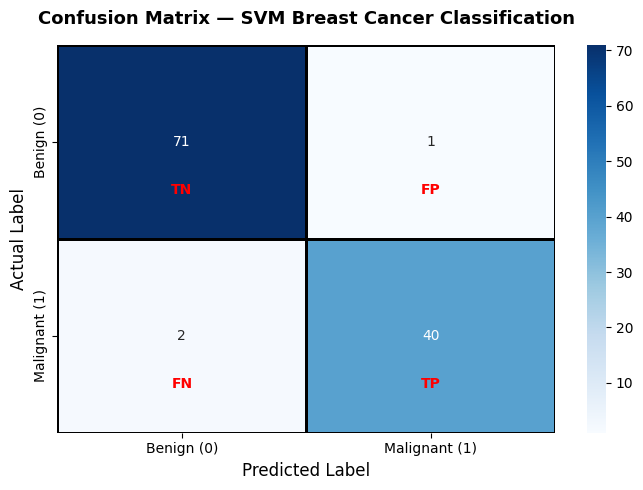

✅ Confusion Matrix saved!


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            linewidths=1,
            linecolor='black',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])

plt.title('Confusion Matrix — SVM Breast Cancer Classification',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

# Add TN, FP, FN, TP labels
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j + 0.5, i + 0.75, labels[i][j],
                 ha='center', va='center',
                 fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved!")

ROC Curve

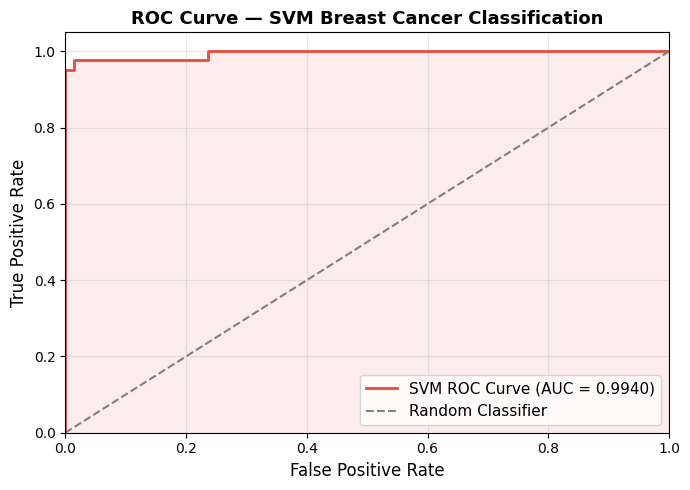

✅ ROC Curve saved!


In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr,
         color='#e74c3c',
         lw=2,
         label=f'SVM ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1],
         color='gray',
         linestyle='--',
         lw=1.5,
         label='Random Classifier')

plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — SVM Breast Cancer Classification',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("✅ ROC Curve saved!")

Sample Predecton Table

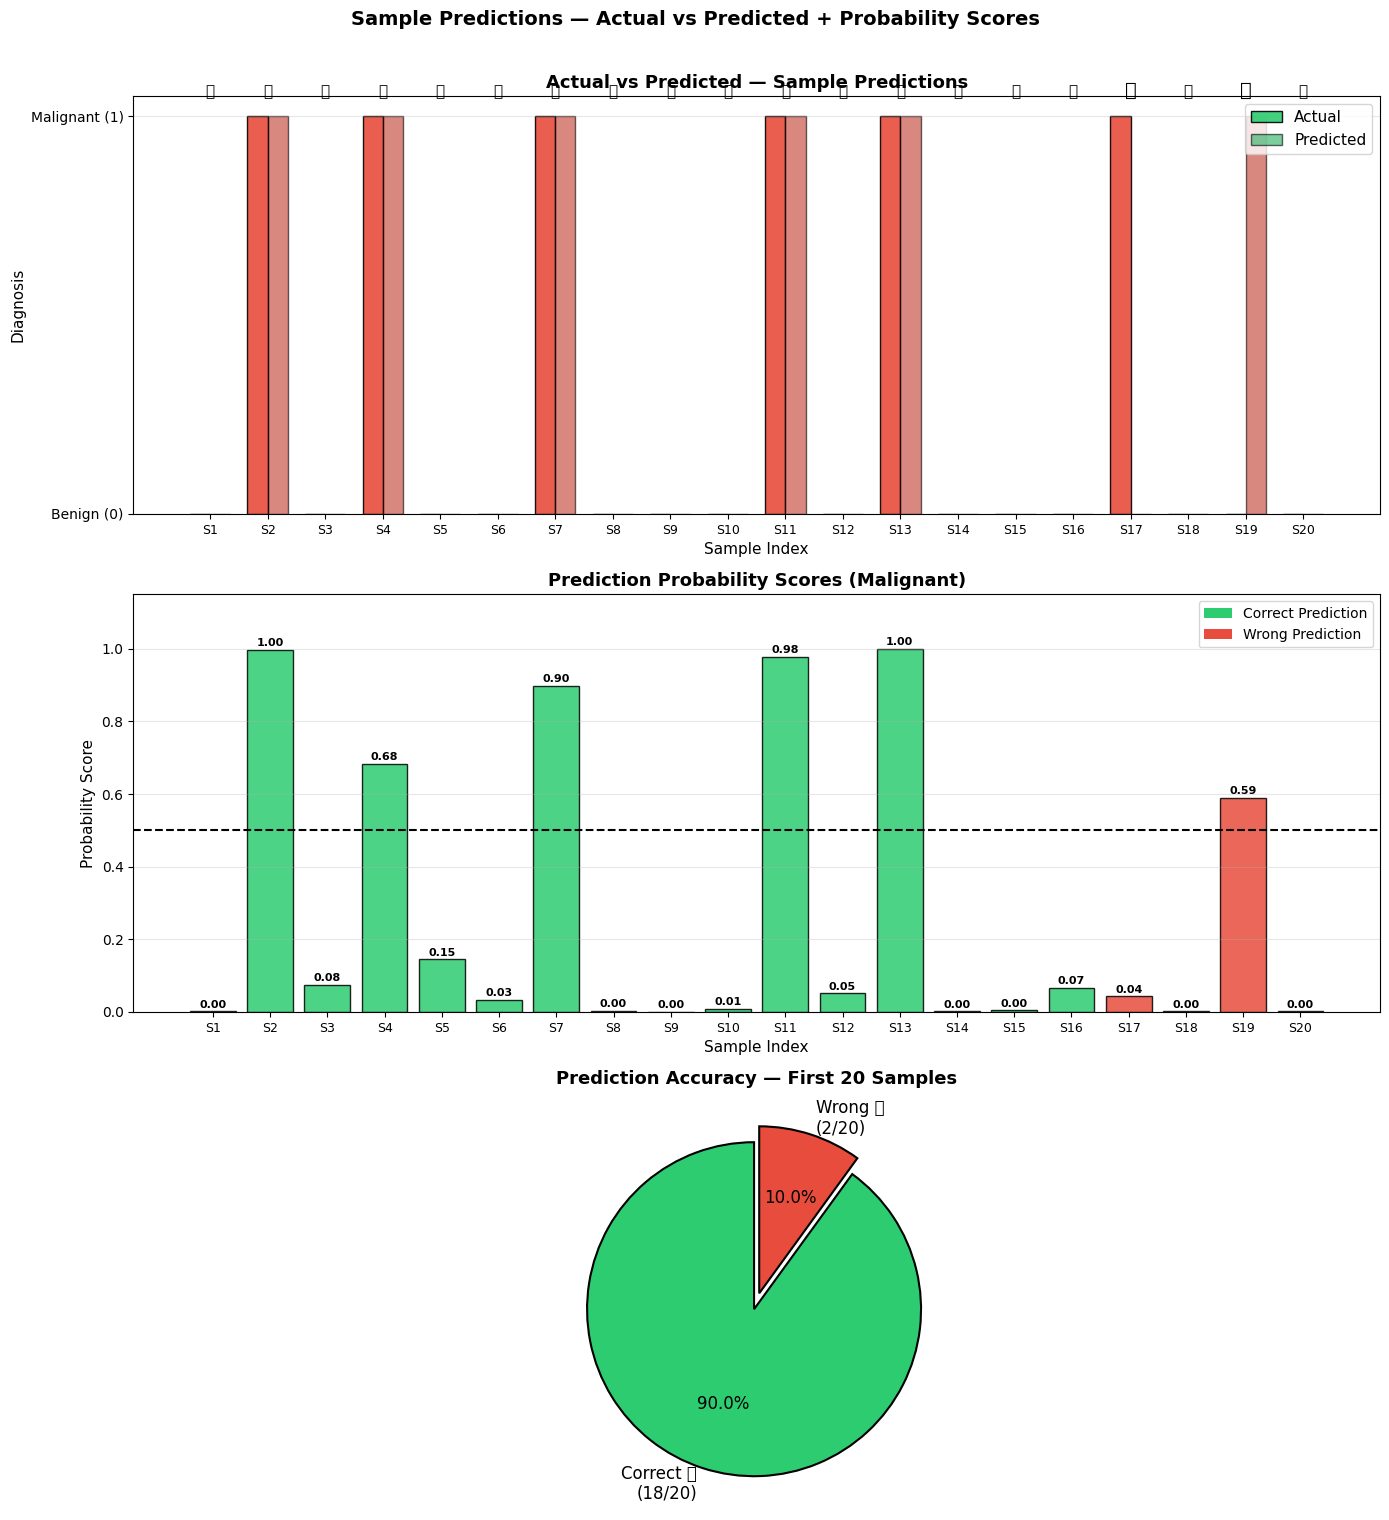

✅ Sample Prediction Plot saved!

📊 Summary:
   ✅ Correct : 18 / 20
   ❌ Wrong   : 2 / 20
   🎯 Accuracy: 90.0%


In [33]:
# Get predictions & probabilities
sample_size = 20
sample_actual    = y_test.values[:sample_size]
sample_predicted = test_pred[:sample_size]
sample_prob      = test_prob[:sample_size]

# Create dataframe
sample_df = pd.DataFrame({
    'Index'           : range(1, sample_size + 1),
    'Actual'          : sample_actual,
    'Predicted'       : sample_predicted,
    'Prob_Malignant'  : sample_prob.round(4),
    'Prob_Benign'     : (1 - sample_prob).round(4),
    'Correct'         : [True if a == p else False
                         for a, p in zip(sample_actual, sample_predicted)]
})

# ============================================
# PLOT 1 — Actual vs Predicted Bar Chart
# ============================================
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

x = np.arange(sample_size)
width = 0.35

# Color mapping
actual_colors    = ['#2ecc71' if v == 0 else '#e74c3c'
                    for v in sample_actual]
predicted_colors = ['#27ae60' if v == 0 else '#c0392b'
                    for v in sample_predicted]

bars1 = axes[0].bar(x - width/2, sample_actual,
                    width,
                    color=actual_colors,
                    edgecolor='black',
                    label='Actual',
                    alpha=0.9)

bars2 = axes[0].bar(x + width/2, sample_predicted,
                    width,
                    color=predicted_colors,
                    edgecolor='black',
                    label='Predicted',
                    alpha=0.6)

# Mark wrong predictions
for i, correct in enumerate(sample_df['Correct']):
    if not correct:
        axes[0].annotate('❌',
                        xy=(i, 1.05),
                        ha='center',
                        fontsize=14)
    else:
        axes[0].annotate('✅',
                        xy=(i, 1.05),
                        ha='center',
                        fontsize=11)

axes[0].set_xticks(x)
axes[0].set_xticklabels([f'S{i}' for i in range(1, sample_size+1)],
                         fontsize=9)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Benign (0)', 'Malignant (1)'], fontsize=10)
axes[0].set_title('Actual vs Predicted — Sample Predictions',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sample Index', fontsize=11)
axes[0].set_ylabel('Diagnosis', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, axis='y')

# ============================================
# PLOT 2 — Probability Bar Chart
# ============================================
prob_colors = ['#2ecc71' if c else '#e74c3c'
               for c in sample_df['Correct']]

bars3 = axes[1].bar(x, sample_prob,
                    color=prob_colors,
                    edgecolor='black',
                    alpha=0.85,
                    label='Prob (Malignant)')

axes[1].axhline(y=0.5,
                color='black',
                linestyle='--',
                linewidth=1.5,
                label='Decision Threshold (0.5)')

# Add probability values on bars
for bar, val in zip(bars3, sample_prob):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}',
                 ha='center',
                 fontsize=8,
                 fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'S{i}' for i in range(1, sample_size+1)],
                         fontsize=9)
axes[1].set_ylim([0, 1.15])
axes[1].set_title('Prediction Probability Scores (Malignant)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sample Index', fontsize=11)
axes[1].set_ylabel('Probability Score', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

# Add correct/wrong color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Correct Prediction'),
    Patch(facecolor='#e74c3c', label='Wrong Prediction')
]
axes[1].legend(handles=legend_elements, fontsize=10, loc='upper right')

# ============================================
# PLOT 3 — Correct vs Wrong Pie Chart
# ============================================
correct_count = sample_df['Correct'].sum()
wrong_count   = sample_size - correct_count

pie_colors  = ['#2ecc71', '#e74c3c']
pie_labels  = [f'Correct ✅\n({correct_count}/{sample_size})',
               f'Wrong ❌\n({wrong_count}/{sample_size})']
pie_explode = (0.05, 0.05)

axes[2].pie([correct_count, wrong_count],
            labels=pie_labels,
            colors=pie_colors,
            explode=pie_explode,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

axes[2].set_title(f'Prediction Accuracy — First {sample_size} Samples',
                  fontsize=13, fontweight='bold')

plt.suptitle('Sample Predictions — Actual vs Predicted + Probability Scores',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_predictions_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Sample Prediction Plot saved!")
print(f"\n📊 Summary:")
print(f"   ✅ Correct : {correct_count} / {sample_size}")
print(f"   ❌ Wrong   : {wrong_count} / {sample_size}")
print(f"   🎯 Accuracy: {correct_count/sample_size*100:.1f}%")

 📊 2D Classification Plot (PCA)

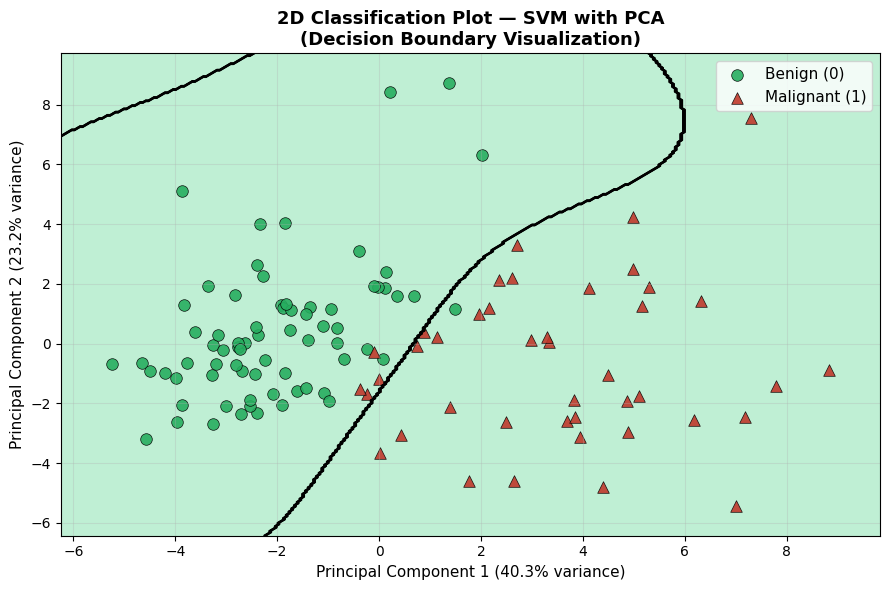

✅ 2D Classification Plot saved!


In [30]:
from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_test_2d  = pca.fit_transform(X_test_scaled)
X_train_2d = pca.transform(X_train_scaled)

# Train SVM on 2D data for decision boundary
svm_2d = SVC(kernel='rbf',
             C=grid_search.best_params_.get('C', 10),
             gamma=grid_search.best_params_.get('gamma', 'scale'),
             probability=True,
             random_state=42)
svm_2d.fit(X_train_2d, y_train)

# Create mesh grid
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

# Predict on mesh
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3,
             colors=['#2ecc71', '#e74c3c'])
plt.contour(xx, yy, Z, colors='black', linewidths=1)

colors  = {0: '#27ae60', 1: '#c0392b'}
markers = {0: 'o', 1: '^'}
labels  = {0: 'Benign (0)', 1: 'Malignant (1)'}

for cls in [0, 1]:
    mask = y_test.values == cls
    plt.scatter(X_test_2d[mask, 0],
                X_test_2d[mask, 1],
                c=colors[cls],
                marker=markers[cls],
                label=labels[cls],
                edgecolors='black',
                linewidths=0.5,
                s=70,
                alpha=0.9)

plt.title('2D Classification Plot — SVM with PCA\n(Decision Boundary Visualization)',
          fontsize=13, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
           fontsize=11)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
           fontsize=11)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('2d_classification_plot.png', dpi=150)
plt.show()
print("✅ 2D Classification Plot saved!")

Final Summary Dashboard

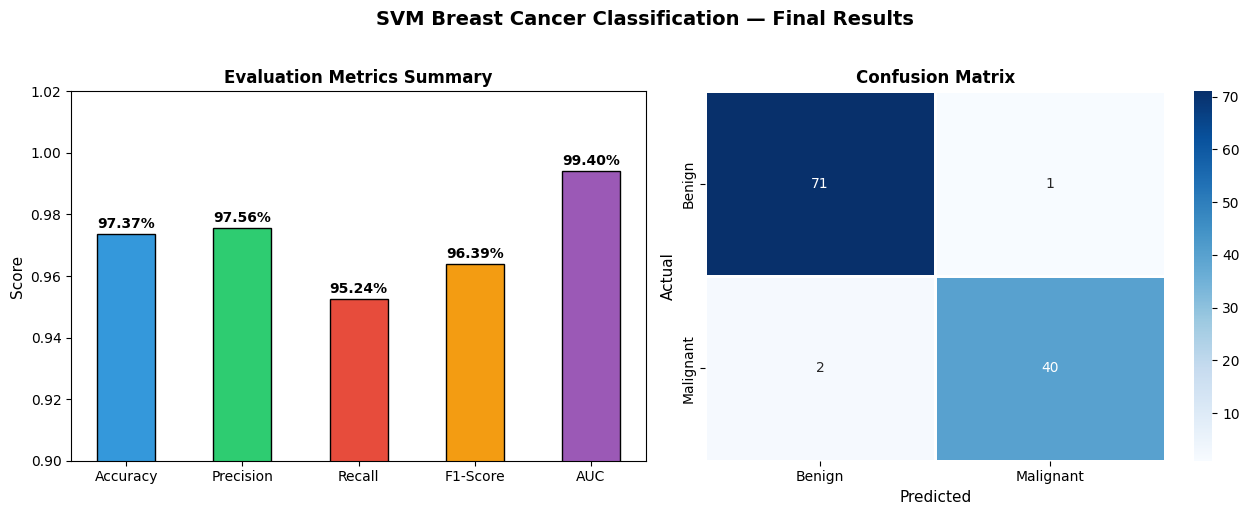

✅ Final Summary Dashboard saved!


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Metrics Bar Chart ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
values  = [accuracy, precision, recall, f1, auc]
colors  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = axes[0].bar(metrics, values, color=colors,
                   edgecolor='black', width=0.5)
axes[0].set_ylim([0.9, 1.02])
axes[0].set_title('Evaluation Metrics Summary',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=11)

for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val*100:.2f}%',
                 ha='center', fontsize=10, fontweight='bold')

# --- Right: Confusion Matrix ---
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[1],
            linewidths=1,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.suptitle('SVM Breast Cancer Classification — Final Results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final Summary Dashboard saved!")

In [32]:
print("=" * 60)
print("     🏆 SVM BREAST CANCER CLASSIFICATION — FINAL REPORT")
print("=" * 60)

print(f"\n📦 DATASET:")
print(f"   Source     : Kaggle — Breast Cancer Dataset")
print(f"   Total Rows : {len(df)}")
print(f"   Features   : {X.shape[1]}")
print(f"   Target     : Benign (0) / Malignant (1)")

print(f"\n📐 DATA SPLIT:")
print(f"   Train      : {X_train.shape[0]} samples (60%)")
print(f"   Validation : {X_val.shape[0]} samples (20%)")
print(f"   Test       : {X_test.shape[0]} samples (20%)")

print(f"\n⚙️  BEST MODEL PARAMETERS:")
print(f"   Kernel     : {grid_search.best_params_.get('kernel')}")
print(f"   C          : {grid_search.best_params_.get('C')}")
print(f"   Gamma      : {grid_search.best_params_.get('gamma', 'N/A')}")
print(f"   Degree     : {grid_search.best_params_.get('degree', 'N/A')}")

print(f"\n📊 EVALUATION METRICS (Test Set):")
print(f"   Accuracy   : {accuracy*100:.2f}%")
print(f"   Precision  : {precision*100:.2f}%")
print(f"   Recall     : {recall*100:.2f}%")
print(f"   F1-Score   : {f1*100:.2f}%")
print(f"   AUC Score  : {auc*100:.2f}%")



print("\n" + "=" * 60)

print("=" * 60)

     🏆 SVM BREAST CANCER CLASSIFICATION — FINAL REPORT

📦 DATASET:
   Source     : Kaggle — Breast Cancer Dataset
   Total Rows : 569
   Features   : 30
   Target     : Benign (0) / Malignant (1)

📐 DATA SPLIT:
   Train      : 341 samples (60%)
   Validation : 114 samples (20%)
   Test       : 114 samples (20%)

⚙️  BEST MODEL PARAMETERS:
   Kernel     : rbf
   C          : 1
   Gamma      : scale
   Degree     : N/A

📊 EVALUATION METRICS (Test Set):
   Accuracy   : 97.37%
   Precision  : 97.56%
   Recall     : 95.24%
   F1-Score   : 96.39%
   AUC Score  : 99.40%



## Summary and Next Steps

You have built and evaluated a Support Vector Machine (SVM) model for breast cancer prediction with impressive results. The model achieved a high accuracy of **97.37%** on the test set, demonstrating its effectiveness in distinguishing between benign and malignant cases.

### Key Accomplishments:
*   **Data Preparation:** Successfully loaded, cleaned, and preprocessed the dataset, including handling missing values, encoding the target variable, and scaling features.
*   **Model Training:** Trained a basic SVM model and optimized its hyperparameters using `GridSearchCV` to find the best configuration.
*   **Comprehensive Evaluation:** Evaluated the model's performance using various metrics (Accuracy, Precision, Recall, F1-Score, AUC) and visualized the results through a Confusion Matrix, ROC Curve, and a 2D PCA Classification Plot.

### What's Next?

Here are some potential next steps and areas for further exploration:

1.  **Interpretability:** Explore methods to understand *why* the model makes certain predictions. For SVMs, examining feature importances (e.g., through permutation importance) can provide insights into which features contribute most to the classification.
2.  **Deployment:** If this model is intended for real-world use, the next phase would be to deploy it. This involves saving the trained model and integrating it into an application or system where it can make predictions on new, unseen data.
3.  **Advanced Models:** While SVM performed well, you could experiment with other advanced machine learning models (e.g., Random Forests, Gradient Boosting, Neural Networks) to see if further performance improvements can be achieved.
4.  **Data Augmentation/Collection:** If more data becomes available, retraining the model with a larger dataset could potentially enhance its robustness and generalization capabilities.
5.  **Uncertainty Quantification:** Investigate methods to quantify the uncertainty in the model's predictions, which can be crucial in medical applications.
6.  **Bias and Fairness:** In healthcare applications, it's vital to assess the model for potential biases across different patient demographics to ensure fairness and prevent disparate impact.